# SIT744 Assignment 4 — Student Submission Template

This template is for organising your submission and reporting results consistently. It is **not** a worked solution. Replace all bracketed text and add your own implementation code where indicated.


## Student and submission details

- **Student name:** Keoma Borges Martins Ferreira Reis
- **Student ID:** 224790234
- **Unit code:** SIT744
- **Assignment:** Assignment 4
- **Date:** 18/05/2026


## Notes

- Keep answers short and to the point.
- Keep code outputs clean; remove excessive logs before exporting to PDF.
- Use the fixed assignment protocol from the brief: `distilgpt2`, the same tokenizer, the required three text files, perplexity, and the fixed generation prompt.
- Use one coherent pipeline across Tasks 1--3.
- The purpose of this template is to make reporting consistent for marking. You are responsible for writing and explaining your own code.


## Fixed protocol summary

| Item | Required setting |
|---|---|
| Base model | `distilgpt2` |
| Tokenizer | tokenizer associated with `distilgpt2` |
| Training text | `undrip_train.txt` |
| Validation text | `undrip_val.txt` |
| Held-out related evaluation text | `economic_test.txt` |
| Required metric | perplexity |
| Generation prompt | `Economic self-determination for First Nations peoples requires` |
| Full fine-tuning | use the fixed configuration from the assignment brief/starter guidance |
| LoRA | use the fixed LoRA configuration from the assignment brief/starter guidance |


## Fixed configuration values for required results

Use the following configuration values for the required Task 2 and Task 3 comparison. These cells specify the controlled protocol only; they do **not** provide the implementation. Do not change these values for the main results reported in the master results table.


In [14]:
# Fixed configuration values for Assignment 4.
# These are provided so all students report results under the same protocol.

BASE_MODEL = "distilgpt2"

TEXT_FILES = {
    "train": "undrip_train.txt",
    "validation": "undrip_val.txt",
    "test": "economic_test.txt",
}

GENERATION_PROMPT = "Economic self-determination for First Nations peoples requires"

TOKENISATION_CONFIG = {
    "block_size": 128,
}

# Settings for perplexity evaluation.
# These are not Hugging Face TrainingArguments.
PERPLEXITY_MAX_LENGTH = 128
PERPLEXITY_STRIDE = 128

GENERATION_CONFIG = {
    "max_new_tokens": 80,
    "do_sample": False,
}


FULL_FINE_TUNING_CONFIG = {
    "output_dir": "./distilgpt2-full-finetuned",
    "num_train_epochs": 1,
    "learning_rate": 5e-5,
    "per_device_train_batch_size": 2,
    "per_device_eval_batch_size": 2,
    "weight_decay": 0.01,
    "logging_steps": 20,
    "save_strategy": "no",
    "report_to": "none",
}

LORA_CONFIG = {
    "r": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "target_modules": ["c_attn"],
    "bias": "none",
    "task_type": "CAUSAL_LM",
}

# LORA_CONFIG controls the LoRA adapter itself: rank, scaling, dropout,
# and target modules.

# LORA_TRAINING_CONFIG controls how the LoRA adapter is trained. 
LORA_TRAINING_CONFIG = {
    "output_dir": "./distilgpt2-lora-finetuned",
    "num_train_epochs": 1,
    "learning_rate": 1e-4,
    "per_device_train_batch_size": 2,
    "per_device_eval_batch_size": 2,
    "weight_decay": 0.01,
    "logging_steps": 20,
    "save_strategy": "no",
    "report_to": "none",
}


In [15]:
# Optional setup for Colab or a fresh environment.
# Uncomment and run this cell if the required packages are not installed.


## Required tokenizer and model setup

In [16]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

# GPT-style tokenizers such as distilgpt2 do not define a separate padding token by default.
# Use the EOS token as the padding token so that batched training/evaluation can run.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

pretrained_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
pretrained_model.resize_token_embeddings(len(tokenizer))
pretrained_model.config.pad_token_id = tokenizer.pad_token_id

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 21782.64it/s]


## Environment and imports

In [17]:
# Add or modify imports as needed for your implementation.
# Keep this cell concise.

import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import torch
import gc

from pathlib import Path
from datasets import Dataset
from transformers import Trainer
from peft import LoraConfig, get_peft_model, TaskType

## Reproducibility

In [18]:
# Reproducibility
# This reduces run-to-run variation in data shuffling, model initialisation, and generation.
# Exact reproducibility is still not guaranteed on all GPU/CUDA setups.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print(f"Seed set to {SEED}")


Seed set to 42


# Task 1 Data preparation and pretrained baseline (25%)

In this task, prepare the three required text files and establish the pretrained baseline.


## Task 1.1 Source documents and extraction method

**Fine-tuning source document:** [Inquiry into the application of the United Nations Declaration on the Rights of Indigenous Peoples in Australia](https://www.aph.gov.au/Parliamentary_Business/Committees/Joint/Aboriginal_and_Torres_Strait_Islander_Affairs/UNDRIP/Report)

**Held-out related evaluation source document:** [Inquiry into economic self-determination and opportunities for First Nations Australians](https://www.aph.gov.au/Parliamentary_Business/Committees/Joint/Aboriginal_and_Torres_Strait_Islander_Affairs/Economicself-determinati/Report)

**Extraction method**  
I downloaded the 2 public reports and converted the PDF files to plain text using pdf24.org. I saved the extracted text as `undrip_raw.txt` and `economic_raw.txt`. I then used the provided preprocessing scaffold to clean the texts and split into an 80/20 train/validation split, and save the cleaned economic report as the held-out test file.


In [19]:
def clean_text(text):
    lines = text.splitlines()
    lines = [line.strip() for line in lines]
    lines = [line for line in lines if len(line) > 0]
    return "\n".join(lines)

def split_text(text, train_ratio=0.8):
    split_index = int(len(text) * train_ratio)
    return text[:split_index], text[split_index:]

# Place your extracted raw plain text into these two files first.
undrip_raw = Path("undrip_raw.txt").read_text(encoding="utf-8")
economic_raw = Path("economic_raw.txt").read_text(encoding="utf-8")

undrip_clean = clean_text(undrip_raw)
economic_clean = clean_text(economic_raw)

undrip_train, undrip_val = split_text(undrip_clean, train_ratio=0.8)

Path("undrip_train.txt").write_text(undrip_train, encoding="utf-8")
Path("undrip_val.txt").write_text(undrip_val, encoding="utf-8")
Path("economic_test.txt").write_text(economic_clean, encoding="utf-8")


452566

## Task 1.2 Data-preparation table

| File | Role | Character count | Approximate token count |
|---|---|----------------:|------------------------:|
| `undrip_train.txt` | training text |          330859 |                   66352 |
| `undrip_val.txt` | validation text |           82715 |                   16276 |
| `economic_test.txt` | held-out related evaluation text |          452566 |                   99776 |


In [20]:
# Optional: code used to compute character counts and approximate token counts.
def count(file_path):
    text = Path(file_path).read_text(encoding="utf-8")
    token_ids = tokenizer.encode(text, add_special_tokens=False)

    return {
        "char count": len(text),
        "token count": len(token_ids),
    }

print(count("undrip_train.txt"))
print(count("undrip_val.txt"))
print(count("economic_test.txt"))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (66352 > 1024). Running this sequence through the model will result in indexing errors


{'char count': 330859, 'token count': 66352}
{'char count': 82715, 'token count': 16276}
{'char count': 452566, 'token count': 99776}


## Task 1.3 Pretrained baseline evaluation

Evaluate pretrained `distilgpt2` on `undrip_val.txt` and `economic_test.txt`. Complete only the pretrained row of the master results table at this stage.


In [21]:
# Pretrained baseline loading and perplexity evaluation code goes here.
# Use pretrained_model for the pretrained baseline.

# Perplexity guidance:
# Use model.eval(), disable gradients, and use labels=input_ids for causal language modelling.
# For long texts, use PERPLEXITY_MAX_LENGTH and PERPLEXITY_STRIDE.
def perplexity(model, tokenizer, file_path, max_length=PERPLEXITY_MAX_LENGTH, stride=PERPLEXITY_STRIDE):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    text = Path(file_path).read_text(encoding="utf-8")
    encodings = tokenizer(text, return_tensors="pt")
    input_ids = encodings.input_ids.to(device)

    seq_len = input_ids.size(1)
    nll_sum = 0.0
    n_tokens = 0
    prev_end_loc = 0

    with torch.no_grad():
        for begin_loc in range(0, seq_len, stride):
            end_loc = min(begin_loc + max_length, seq_len)
            trg_len = end_loc - prev_end_loc

            input_ids_slice = input_ids[:, begin_loc:end_loc]
            target_ids = input_ids_slice.clone()
            target_ids[:, :-trg_len] = -100

            outputs = model(input_ids_slice, labels=target_ids)
            neg_log_likelihood = outputs.loss

            nll_sum += neg_log_likelihood.item() * trg_len
            n_tokens += trg_len

            prev_end_loc = end_loc

            if end_loc == seq_len:
                break

    return math.exp(nll_sum / n_tokens)

pretrained_val_ppl = perplexity(
    pretrained_model,
    tokenizer,
    "undrip_val.txt",
)

pretrained_economic_ppl = perplexity(
    pretrained_model,
    tokenizer,
    "economic_test.txt",
)

print(f"pretrained_val_ppl: {pretrained_val_ppl}")
print(f"pretrained_economic_ppl: {pretrained_economic_ppl}")

pretrained_val_ppl: 53.34027397216509
pretrained_economic_ppl: 60.87435530123492


## Master results table

Complete this table across Tasks 1-3.

Training time depends on the runtime environment, so use it mainly for comparing your own full fine-tuning and LoRA runs under the same setup.

| Model state | Parameters updated during adaptation | Training time (minutes; compare within the same runtime) | PPL on UNDRIP validation | PPL on Economic test |
|---|-------------------------------------:|---------------------------------------------------------:|---:|---------------------:|
| Pretrained `distilgpt2` |                                    0 |                                                        0 | 53.340 |               60.874 |
| Full fine-tuned `distilgpt2` |                             81912576 |                                                    0.438 | 31.367 |            47.560 |
| LoRA-adapted `distilgpt2` |                               147456 |                                                    0.210 | 46.883 |            54.430 |


# Task 2 Full fine-tuning (25%)

Fine-tune `distilgpt2` once using the fixed full fine-tuning configuration. Report the result in the master results table.


In [22]:
# Start full fine-tuning from a fresh pretrained model.
model_full = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
model_full.resize_token_embeddings(len(tokenizer))
model_full.config.pad_token_id = tokenizer.pad_token_id

# Full fine-tuning code goes here.
# Use FULL_FINE_TUNING_CONFIG for the required main result.
# Keep the base model, tokenizer, training text, validation text, test text,
# evaluation metric, and generation prompt fixed.

# empty cache
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Build fixed-size token blocks for causal language modelling.
def build_causal_lm_dataset(file_path, tokenizer, block_size):
    text = Path(file_path).read_text(encoding="utf-8")

    token_ids = tokenizer(
        text,
        add_special_tokens=False,
        return_attention_mask=False,
        truncation=False,
        verbose=False,
    )["input_ids"]

    total_length = (len(token_ids) // block_size) * block_size
    token_ids = token_ids[:total_length]

    input_blocks = [
        token_ids[i : i + block_size]
        for i in range(0, total_length, block_size)
    ]

    attention_masks = [
        [1] * block_size
        for _ in input_blocks
    ]

    labels = [
        block.copy()
        for block in input_blocks
    ]

    return Dataset.from_dict({
        "input_ids": input_blocks,
        "attention_mask": attention_masks,
        "labels": labels,
    })

block_size = TOKENISATION_CONFIG["block_size"]

train_dataset = build_causal_lm_dataset(
    TEXT_FILES["train"],
    tokenizer,
    block_size,
)

print(train_dataset)

# load a fresh pretrained model for full fine-tuning.
model_full = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
model_full.resize_token_embeddings(len(tokenizer))
model_full.config.pad_token_id = tokenizer.pad_token_id
model_full.config.use_cache = False

# Count all trainable parameters in the full fine-tuning model.
full_trainable_params = sum(
    param.numel()
    for param in model_full.parameters()
    if param.requires_grad
)

full_total_params = sum(
    param.numel()
    for param in model_full.parameters()
)

print(f"full_total_params: {full_total_params:,}")
print(f"full_trainable_params: {full_trainable_params:,}")

full_training_config = FULL_FINE_TUNING_CONFIG.copy()
full_training_config["seed"] = SEED
full_training_config["data_seed"] = SEED

full_training_args = TrainingArguments(**full_training_config)

# Create the Trainer for full fine-tuning.
full_trainer = Trainer(
    model=model_full,
    args=full_training_args,
    train_dataset=train_dataset,
)

# Train and measure
start_time = time.time()
full_train_output = full_trainer.train()
end_time = time.time()

full_training_time_minutes = (end_time - start_time) / 60
full_final_training_loss = full_train_output.training_loss

print(f"full_training_time_minutes: {full_training_time_minutes:.4f}")
print(f"full_final_training_loss: {full_final_training_loss:.4f}")

# store the logged training loss values.
full_loss_history = pd.DataFrame([
    log
    for log in full_trainer.state.log_history
    if "loss" in log
])

# Evaluate the full fine-tuned model on validation and held-out test text.
full_val_ppl = perplexity(
    model_full,
    tokenizer,
    TEXT_FILES["validation"],
)

full_economic_ppl = perplexity(
    model_full,
    tokenizer,
    TEXT_FILES["test"],
)

print(f"full_val_ppl: {full_val_ppl}")
print(f"full_economic_ppl: {full_economic_ppl}")

# Re-enable cache for later text generation.
model_full.config.use_cache = True

print({
    "Model": "Full fine-tuned distilgpt2",
    "full_trainable_params": full_trainable_params,
    "full_training_time_minutes": full_training_time_minutes,
    "full_val_ppl": full_val_ppl,
    "full_economic_ppl": full_economic_ppl,
})

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 10224.76it/s]


Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 518
})


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 9244.45it/s]


full_total_params: 81,912,576
full_trainable_params: 81,912,576


/Users/kreis/grad/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
20,3.745292
40,3.564964
60,3.651625
80,3.474891
100,3.359238
120,3.352230
140,3.373321
160,3.367283
180,3.241604
200,3.303735


full_training_time_minutes: 0.4384
full_final_training_loss: 3.4354
full_val_ppl: 31.36750990873973
full_economic_ppl: 47.56009730971566
{'Model': 'Full fine-tuned distilgpt2', 'full_trainable_params': 81912576, 'full_training_time_minutes': 0.4384010990460714, 'full_val_ppl': 31.36750990873973, 'full_economic_ppl': 47.56009730971566}


## Task 2 evidence

Include either a training-loss curve or a compact final training-loss record.


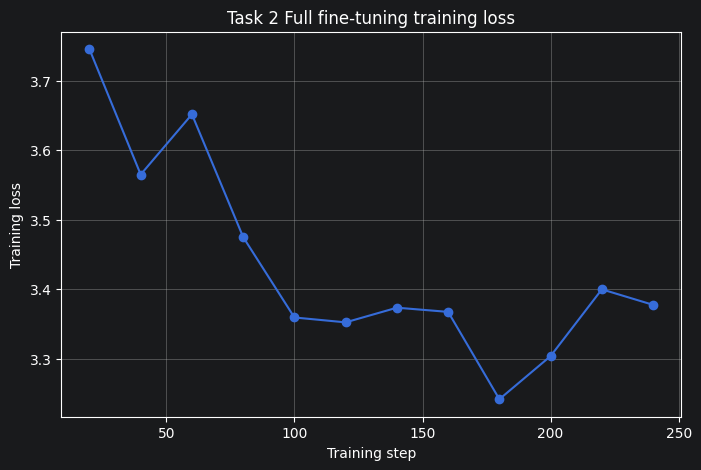

,step,loss,epoch
0,20,3.745292,0.077220
1,40,3.564964,0.154440
2,60,3.651625,0.231660
3,80,3.474891,0.308880
4,100,3.359238,0.386100
5,120,3.352230,0.463320
6,140,3.373321,0.540541
7,160,3.367283,0.617761
8,180,3.241604,0.694981
9,200,3.303735,0.772201


In [23]:
# Plot the training-loss curve or print a compact final training-loss record here.

if len(full_loss_history) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(full_loss_history["step"], full_loss_history["loss"], marker="o")
    plt.title("Task 2 Full fine-tuning training loss")
    plt.xlabel("Training step")
    plt.ylabel("Training loss")
    plt.grid(True)
    plt.show()

    display(full_loss_history[["step", "loss", "epoch"]])
else:
    print(f"full_final_training_loss: {full_final_training_loss:.4f}")


# Task 3 LoRA adaptation and comparison (25%)

Train a LoRA-adapted version of `distilgpt2` using the fixed LoRA configuration. Reload a fresh distilgpt2 base model before applying LoRA. Do not apply LoRA to the full fine-tuned model from Task 2.
Report the result in the master results table.


In [24]:
# Start LoRA from a fresh pretrained model, not from the full fine-tuned model.
lora_base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
lora_base_model.resize_token_embeddings(len(tokenizer))
lora_base_model.config.pad_token_id = tokenizer.pad_token_id

# LoRA adaptation and evaluation code goes here.
# Use LORA_CONFIG for the required main result.
lora_training_args = TrainingArguments(**LORA_TRAINING_CONFIG)
# Apply LoRA to lora_base_model and store the adapted model as lora_model.
# Do not apply LoRA on top of the full fine-tuned model for the required comparison.

# Clear memory before training the LoRA model.
for model_name in ["pretrained_model", "model_full"]:
    if model_name in globals():
        globals()[model_name].to("cpu")
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Reuse the same training dataset as the full fine-tuning task
lora_train_dataset = build_causal_lm_dataset(
    TEXT_FILES["train"],
    tokenizer,
    TOKENISATION_CONFIG["block_size"],
)

print(lora_train_dataset)

# Load a fresh pretrained model for LoRA adaptation.
lora_base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
lora_base_model.resize_token_embeddings(len(tokenizer))
lora_base_model.config.pad_token_id = tokenizer.pad_token_id
lora_base_model.config.use_cache = False

# Convert the task type to the PEFT enum if needed.
lora_config_values = LORA_CONFIG.copy()

if lora_config_values.get("task_type") == "CAUSAL_LM":
    lora_config_values["task_type"] = TaskType.CAUSAL_LM

# Create the LoRA configuration and apply to the fresh base model.
lora_config = LoraConfig(**lora_config_values)
lora_model = get_peft_model(lora_base_model, lora_config)

# Count the trainable LoRA parameters.
lora_trainable_params = sum(
    param.numel()
    for param in lora_model.parameters()
    if param.requires_grad
)

lora_total_params = sum(
    param.numel()
    for param in lora_model.parameters()
)

lora_trainable_percentage = 100 * lora_trainable_params / lora_total_params

print(f"lora_total_params: {lora_total_params:,}")
print(f"lora_trainable_params: {lora_trainable_params:,}")
print(f"lora_trainable_percentage: {lora_trainable_percentage:.4f}%")

# Use the fixed lora training configuration from the template.
lora_training_config = LORA_TRAINING_CONFIG.copy()
lora_training_config["seed"] = SEED
lora_training_config["data_seed"] = SEED

lora_training_args = TrainingArguments(**lora_training_config)

# Create the Trainer for lora adaptation.
lora_trainer = Trainer(
    model=lora_model,
    args=lora_training_args,
    train_dataset=lora_train_dataset,
)

# Train and measure runtime.
start_time = time.time()
lora_train_output = lora_trainer.train()
end_time = time.time()

lora_training_time_minutes = (end_time - start_time) / 60
lora_final_training_loss = lora_train_output.training_loss

print(f"lora_training_time_minutes: {lora_training_time_minutes:.4f}")
print(f"lora_final_training_loss: {lora_final_training_loss:.4f}")

# Store the logged lora loss values
lora_loss_history = pd.DataFrame([
    log
    for log in lora_trainer.state.log_history
    if "loss" in log
])

display(lora_loss_history)

# Evaluate the lora model on validation and held-out test text
lora_val_ppl = perplexity(
    lora_model,
    tokenizer,
    TEXT_FILES["validation"],
)

lora_economic_ppl = perplexity(
    lora_model,
    tokenizer,
    TEXT_FILES["test"],
)

print(f"lora_val_ppl: {lora_val_ppl}")
print(f"lora_economic_ppl: {lora_economic_ppl}")

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 14412.76it/s]


Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 518
})


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 18143.72it/s]
/Users/kreis/grad/.venv/lib/python3.14/site-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


lora_total_params: 82,060,032
lora_trainable_params: 147,456
lora_trainable_percentage: 0.1797%


/Users/kreis/grad/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
20,3.912324
40,3.911057
60,4.035173
80,3.907057
100,3.840323
120,3.809565
140,3.851002
160,3.798187
180,3.702686
200,3.734011


lora_training_time_minutes: 0.2105
lora_final_training_loss: 3.8596


,loss,grad_norm,learning_rate,epoch,step
0,3.912324,0.227272,0.000093,0.077220,20
1,3.911057,0.300939,0.000085,0.154440,40
2,4.035173,0.323168,0.000077,0.231660,60
3,3.907057,0.577884,0.000069,0.308880,80
4,3.840323,0.499914,0.000062,0.386100,100
5,3.809565,0.551255,0.000054,0.463320,120
6,3.851002,0.478323,0.000046,0.540541,140
7,3.798187,0.609105,0.000039,0.617761,160
8,3.702686,0.565506,0.000031,0.694981,180
9,3.734011,0.635913,0.000023,0.772201,200


lora_val_ppl: 46.88389397659971
lora_economic_ppl: 54.43052729258307


## Generation comparison table

Use the fixed generation prompt exactly. Keep outputs short enough to be readable in the exported PDF.

| Prompt | Pretrained output | Full fine-tuned output | LoRA-adapted output | One-sentence comparison                                                                                                                       |
|---|---|---|---|-----------------------------------------------------------------------------------------------------------------------------------------------|
| `Economic self-determination for First Nations peoples requires` | a strong commitment to the rights of all peoples. | a national government to implement the Declaration. 1.1 The UNDRIP is a national document that provides for the implementation of the Declaration. It is a document that provides for the implementation of the Declaration. 1.2 The Declaration is a document that provides for the implementation of the Declaration. 1.3 The Declaration is a document that provides for the implementation of the Declaration. 1 | a comprehensive and comprehensive international framework to address the challenges facing First Nations peoples. The United Nations Framework Convention on the Rights of Indigenous Peoples (UNFPA) is a comprehensive and comprehensive international framework for the development of First Nations peoples. The UNFPA is a comprehensive and comprehensive international framework for the development of First Nations peoples. The UNFPA is a comprehensive and comprehensive international framework | The full fine-tuned output more specific while the LoRA output is not so accurate and more repetitive. The pretrained output is more generic. |


In [25]:
# Generation code for pretrained_model, full_model, and lora_model goes here.
# Use GENERATION_PROMPT and GENERATION_CONFIG for the required comparison.

# Generate a continuation for the fixed assignment prompt.
def generate_continuation(model, tokenizer, prompt, generation_config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    model.eval()

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=generation_config["max_new_tokens"],
            do_sample=generation_config["do_sample"],
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    prompt_length = inputs["input_ids"].shape[-1]
    continuation_ids = generated_ids[0][prompt_length:]

    continuation = tokenizer.decode(
        continuation_ids,
        skip_special_tokens=True,
    )

    return " ".join(continuation.split())

# Generate text from the pretrained baseline
pretrained_output = generate_continuation(
    pretrained_model,
    tokenizer,
    GENERATION_PROMPT,
    GENERATION_CONFIG,
)

pretrained_model.to("cpu")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Generate text from the full fine-tuned model
full_output = generate_continuation(
    model_full,
    tokenizer,
    GENERATION_PROMPT,
    GENERATION_CONFIG,
)

model_full.to("cpu")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Generate text from the lora model
lora_output = generate_continuation(
    lora_model,
    tokenizer,
    GENERATION_PROMPT,
    GENERATION_CONFIG,
)

lora_model.to("cpu")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Keep the full text visible in the notebook output.
pd.set_option("display.max_colwidth", None)

print("pretrained output:")
print(pretrained_output)
print()

print("fine-tuned output:")
print(full_output)
print()

print("lora output:")
print(lora_output)

pretrained output:
a strong commitment to the rights of all peoples.

fine-tuned output:
a national government to implement the Declaration. 1.1 The UNDRIP is a national document that provides for the implementation of the Declaration. It is a document that provides for the implementation of the Declaration. 1.2 The Declaration is a document that provides for the implementation of the Declaration. 1.3 The Declaration is a document that provides for the implementation of the Declaration. 1

lora output:
a comprehensive and comprehensive international framework to address the challenges facing First Nations peoples. The United Nations Framework Convention on the Rights of Indigenous Peoples (UNFPA) is a comprehensive and comprehensive international framework for the development of First Nations peoples. The UNFPA is a comprehensive and comprehensive international framework for the development of First Nations peoples. The UNFPA is a comprehensive and comprehensive international framework

# Task 4 Interpretation and learning reflection (20%)

This task is about explanation and evidence of your individual learning.


## Task 4A Technical interpretation (15%)

Answer the following questions in at most **300 words** total. Your answers must refer to your own master results table and generation comparison table.

1. Using your reported perplexity values, what do your results show about adaptation to `undrip_val.txt` versus transfer to `economic_test.txt`?
2. Using your reported trainable-parameter count, training time, perplexity values, and generation comparison, what trade-off do you observe between full fine-tuning and LoRA?
3. Based on your own results, which method would you recommend under limited compute for a quick domain-adaptation baseline, and why?

Before writing, look at your master results table and generation comparison table. Your discussion should refer to your own reported values. For example: "Full fine-tuning reduced PPL on UNDRIP validation from X to Y, while LoRA reduced it to Z."

**Your response:**  
The perplexity results show that both adaptation methods improved the model compared with the pretrained baseline. On the UNDRIP validation text, perplexity decreased from 53.34 for pretrained distilgpt2 to 31.37 after full fine-tuning and 46.88 after LoRA. This shows that full fine-tuning adapted much more strongly to the UNDRIP domain. On the held-out Economic test text, perplexity decreased from 60.87 to 47.56 with full fine-tuning and to 54.43 with LoRA. This suggests some transfer to the related parliamentary-report domain, although the improvement was smaller than on the UNDRIP validation text.

The trade-off is that full fine-tuning gave the best perplexity and the most domain-specific generated output, but it updated 81,912,576 parameters and took 0.41 minutes. LoRA updated only 147,456 parameters and took 0.20 minutes, but its perplexity improvement was smaller and its generated output was more repetitive. Under limited compute, I would recommend LoRA as a quick domain-adaptation baseline because it improved both evaluation perplexities while training far fewer parameters and taking about half the time. However, if the goal is the strongest adaptation quality, full fine-tuning performed better in my results.


## Task 4B Learning reflection (5%)

Answer the following question in at most **150 words**.

Over the 11 weeks of this unit, what is one intuition about deep learning that has changed, become clearer, or become more nuanced for you?

Your answer should include:

- one earlier intuition, assumption, or misconception;
- the concept, activity, result, lecture, practical, or example that changed or refined it;
- what you now understand differently;
- how this would affect the way you approach a future deep learning problem.

**Your response:**  
Earlier in the unit, I assumed that improving a deep learning model mainly meant training more parameters or using a larger model. This assignment made that idea more nuanced because LoRA improved the pretrained model while updating only 147,456 parameters, compared with 81,912,576 parameters in full fine-tuning. The result helped me understand that adaptation quality is not only about model size, but also about choosing an efficient training method and evaluating it fairly. I now understand why controlled comparisons matter: the same tokenizer, files, prompt, and perplexity calculation made the trade-off between full fine-tuning and LoRA visible. In a future deep learning problem, I would first build a simple baseline and then test a lighter adaptation method before choosing a more expensive full fine-tuning approach.


# Final checklist

- [ ] The notebook filename follows the required format.
- [ ] The PDF export filename follows the required format.
- [ ] `undrip_train.txt`, `undrip_val.txt`, and `economic_test.txt` are submitted.
- [ ] The 80/20 UNDRIP split is followed.
- [ ] All modelling tasks use the text files created in Task 1.
- [ ] The data-preparation table is completed.
- [ ] The master results table is completed.
- [ ] A training-loss curve or compact final training-loss record is included.
- [ ] The generation comparison table is completed.
- [ ] The fixed generation prompt is used exactly.
- [ ] Perplexity is reported consistently.
- [ ] The technical interpretation is concise.
- [ ] My technical interpretation refers to my own master results table and generation comparison table.
- [ ] The learning reflection identifies a concrete change in understanding.
- [ ] Code outputs are cleaned before PDF export.
- [ ] Cloud resources are shut down after use.
